In [ ]:
%pip install --force-reinstall -v "tensorflow==2.19"
%pip install pandas keras keras_tuner

In [ ]:
%pip install matplotlib seaborn scikit-learn
%pip install mlflow pandas

In [2]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import mlflow
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import initializers


mlflow.set_experiment("classification_experiments")
import matplotlib.pyplot as plt



In [3]:
input_file_path = "FootballPlayerPreparedCleanAttributes.csv"
output_file_path = "FootballPlayerOneHotEncodedClasses.csv"
input_dataframe = pd.read_csv(input_file_path)
output_dataframe = pd.read_csv(output_file_path)

In [4]:
seed_1 = 42
seed_2 = 24

train_x = input_dataframe.sample(frac = 0.8, random_state=seed_1)
test_temp_x = input_dataframe.drop(train_x.index)
test_x = test_temp_x.sample(frac = 0.5, random_state=seed_2)
validate_x = test_temp_x.drop(test_x.index)

train_y = output_dataframe.loc[train_x.index]
test_y = output_dataframe.loc[test_x.index]
validate_y = output_dataframe.loc[validate_x.index]


In [5]:
train_x.shape

(12907, 22)

RUN MODEL AND STORE IN ML FLOW

Epoch 1/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6187 - loss: 4.3759 - val_accuracy: 0.7299 - val_loss: 3.6815
Epoch 2/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7233 - loss: 3.3451 - val_accuracy: 0.7763 - val_loss: 2.8978
Epoch 3/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7601 - loss: 2.6872 - val_accuracy: 0.7955 - val_loss: 2.3626
Epoch 4/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7924 - loss: 2.2134 - val_accuracy: 0.8296 - val_loss: 1.9704
Epoch 5/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8068 - loss: 1.8846 - val_accuracy: 0.8154 - val_loss: 1.7262
Epoch 6/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8175 - loss: 1.6280 - val_accuracy: 0.8420 - val_loss: 1.4935
Epoch 7/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8252 - loss: 1.4357 - val_accuracy: 0.8432 - val_loss: 1.3163
Epoch 8/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8254 - loss: 1.2908 - val_acc

2025/12/04 14:28:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/04 14:28:34 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/12/04 14:28:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


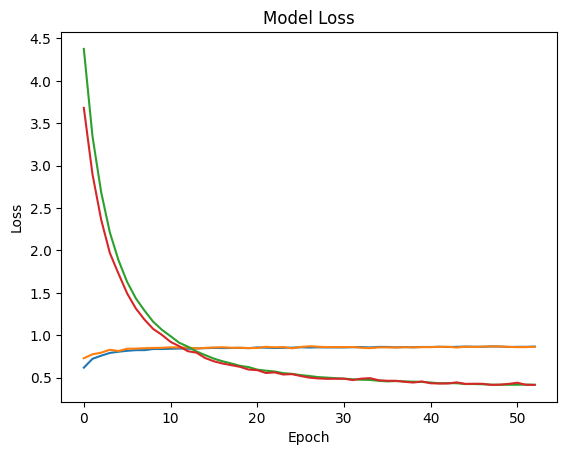

In [6]:
with mlflow.start_run(run_name=f"R-20. Final run") as run:
    
    # Log hyperparameters
    mlflow.log_param("Activation", "relu")
    mlflow.log_param("Dropout_rate", 0.15)
    mlflow.log_param("Batch_size", 128)
    mlflow.log_param("Epochs", 200)
    mlflow.log_param("Shape", "512, 512, 256, 64")
    mlflow.log_param("Optimizer", "Adam")
    mlflow.log_param("Loss", "categorical_crossentropy")
    mlflow.log_param("Regularizers", "L2-0.0015")
    mlflow.log_param("Early stop", "Yes - 5")
    mlflow.log_param("Initializer", "he_normal")
    mlflow.log_param("BatchNormalization", "No")

    mlflow.log_param("Notes", "")
    
    model = keras.Sequential([
        layers.Input(shape=(22,)),

        layers.Dense(512, kernel_regularizer=keras.regularizers.L2(0.0015), kernel_initializer="he_normal"),
        #layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.15),
        
        layers.Dense(512, kernel_regularizer=keras.regularizers.L2(0.0015), kernel_initializer="he_normal"),
        #layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.15),
        
        layers.Dense(256, kernel_regularizer=keras.regularizers.L2(0.0015), kernel_initializer="he_normal"),
        #layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.15),
        
        layers.Dense(64, kernel_regularizer=keras.regularizers.L2(0.0015), kernel_initializer="he_normal"),
        #layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.15),

        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

    history = model.fit(
        train_x, train_y,
        validation_data=(test_x, test_y),
        epochs=200,
        batch_size=128,
        verbose=1,
        callbacks=[early_stop]
    )
    
    # Log metrics (final epoch metrics)
    mlflow.log_metric("train_accuracy", history.history['accuracy'][-1])
    mlflow.log_metric("val_accuracy", history.history['val_accuracy'][-1])
    mlflow.log_metric("train_loss", history.history['loss'][-1])
    mlflow.log_metric("val_loss", history.history['val_loss'][-1])

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.savefig("accuracy.png")
    mlflow.log_artifact("accuracy.png")
    # Loss
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.savefig("loss.png")
    mlflow.log_artifact("loss.png")
    
    # Log the trained Keras model
    mlflow.keras.log_model(model, "keras_model")

TEST MY MODEL

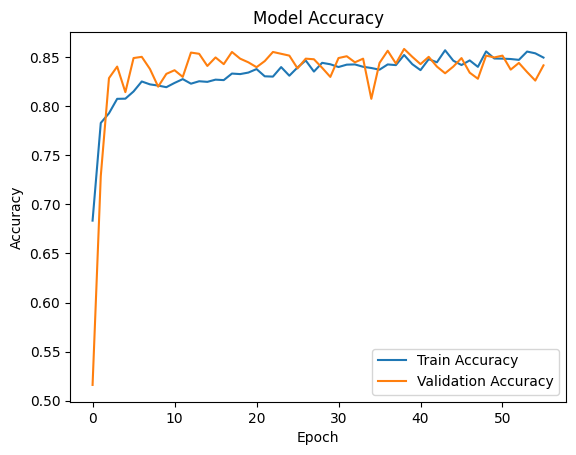

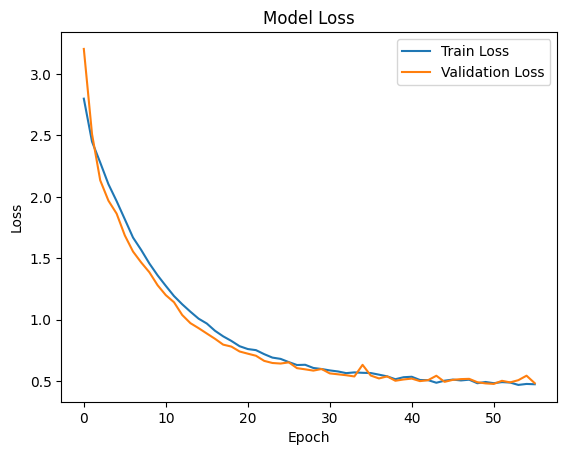

In [58]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


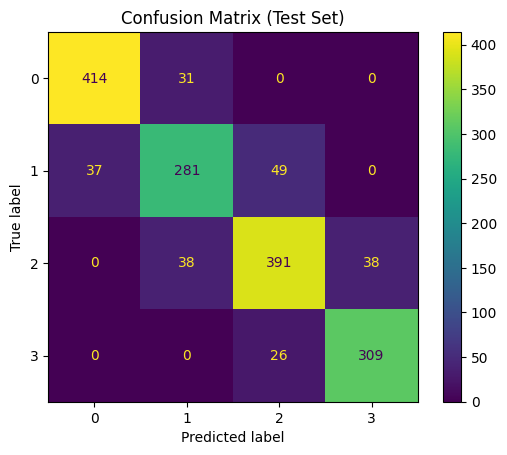

In [162]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(test_x), axis=1)
y_true = np.argmax(test_y.values, axis=1)

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.title("Confusion Matrix (Test Set)")
plt.show()


FIND A GOOD MODEL USING KERAS_TUNER

In [34]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
def build_model(hp):
    model = keras.Sequential()
    
    # Input layer (fixed 22 features)
    model.add(layers.Input(shape=(22,)))
    
    # Tune number of hidden layers: between 1 and 3
    for i in range(hp.Int('num_layers', 1, 3)):
        for activation in ['relu', 'tanh']:
            model.add(layers.Dense(
                units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
                activation = activation
            ))
            # Tune dropout rate per layer
            model.add(layers.Dropout(
                rate=hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)
            ))

    # Output layer
    model.add(layers.Dense(4, activation='softmax'))

    # Tune learning rate for the Adam optimizer
    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [35]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    directory='tuner_results',
    project_name='dnn_tuning'
)


Reloading Tuner from tuner_results/dnn_tuning/tuner0.json


In [36]:
stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    train_x, train_y,
    epochs=50,
    validation_data=(test_x, test_y),
    callbacks=[stop_early],
    verbose=1
)


LOAD OLD MODELS FROM ML FLOW

In [45]:

# To read models form ml flow. 
# Replace this with your run_id
run_id = "1777fc6480c748548f94b585f0f756d6"

# Load the model back
loaded_model = mlflow.keras.load_model(f"runs:/{run_id}/keras_model")

#history_loaded_model = loaded_model.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=50)
history_loaded_model = loaded_model.fit(
        train_x, train_y,
        validation_data=(test_x, test_y),
        epochs=50,
        batch_size=64,
        verbose=1
    )

Epoch 1/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8676 - loss: 0.3844 - val_accuracy: 0.8581 - val_loss: 0.3896
Epoch 2/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8653 - loss: 0.3842 - val_accuracy: 0.8532 - val_loss: 0.3876
Epoch 3/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8641 - loss: 0.3858 - val_accuracy: 0.8556 - val_loss: 0.4056
Epoch 4/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8670 - loss: 0.3833 - val_accuracy: 0.8575 - val_loss: 0.3905
Epoch 5/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8649 - loss: 0.3872 - val_accuracy: 0.8525 - val_loss: 0.4000
Epoch 6/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8647 - loss: 0.3849 - val_accuracy: 0.8575 - val_loss: 0.3869
Epoch 7/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8646 - loss: 0.3868 - val_accuracy: 0.8432 - val_loss: 0.4132
Epoch 8/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8652 - loss: 0.3823 - val_accuracy: 0.

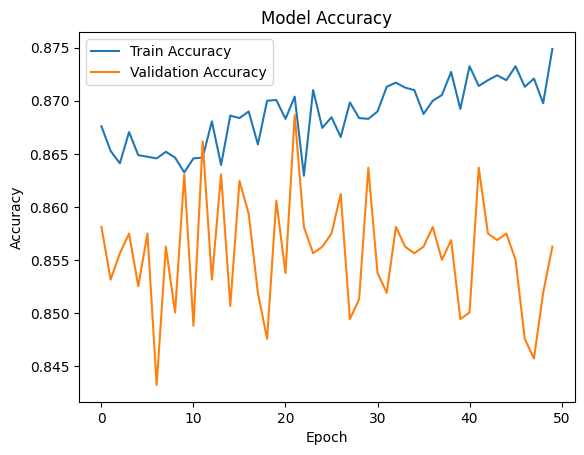

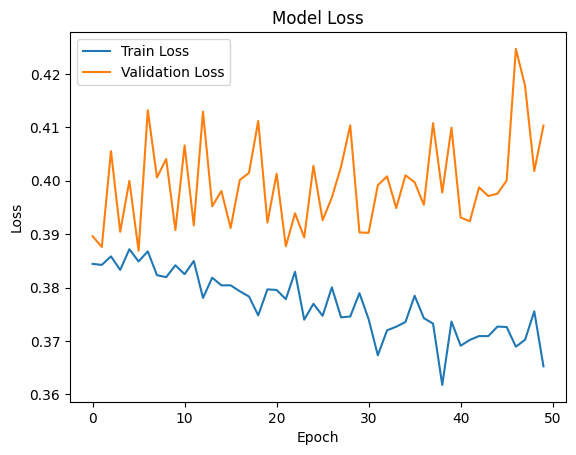

In [47]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_loaded_model.history['accuracy'], label='Train Accuracy')
plt.plot(history_loaded_model.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history_loaded_model.history['loss'], label='Train Loss')
plt.plot(history_loaded_model.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
#Loaded model characteristics
loaded_model.summary()
from tensorflow.keras.utils import plot_model

# This will save the architecture to a PNG file
plot_model(
    loaded_model,
    to_file='model_architecture.png',
    show_shapes=True,         # Show output shapes
    show_layer_names=True,    # Show layer names
    show_layer_activations=True # Show activation functions
)

config = loaded_model.get_config()

# It's a nested dictionary, so printing it nicely helps
import json
print(json.dumps(config, indent=2))

In [ ]:
# Get the optimizer's full configuration
optimizer_config = loaded_model.optimizer.get_config()

# Get the optimizer's name
optimizer_name = optimizer_config['name']

# Get the learning rate
# It might be nested under 'learning_rate' or just be a top-level key
if 'learning_rate' in optimizer_config:
    lr = optimizer_config['learning_rate']
else:
    # Some optimizers store it differently (e.g., in a schedule)
    # This is a common fallback.
    lr = loaded_model.optimizer.learning_rate

print(f"Optimizer Name: {optimizer_name}")
print(f"Learning Rate: {lr}")

# You can also print the whole config to see everything
print("\n--- Full Optimizer Config ---")
import json
print(json.dumps(optimizer_config, indent=2))

In [24]:
#make notes on the model I just loaded from ml flow
mlflow.set_tag("notes", "Model reached 90% accuracy but shows signs of overfitting (val_loss increasing after epoch 8).")

In [156]:
# predict on validation set
predictions = model.predict(validate_x)

from sklearn.metrics import accuracy_score

# Convert probabilities to class labels using a 0.5 threshold
# (predictions > 0.5) creates a boolean array, .astype(int) converts True/False to 1/0
predicted_classes = (predictions > 0.5).astype(int)

# Now, compare the predicted classes to the true classes
acc = accuracy_score(validate_y, predicted_classes)
print(f"New Validation Accuracy: {acc:.4f}")


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
New Validation Accuracy: 0.8568


In [160]:
loss, acc = model.evaluate(validate_x, validate_y, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc:.4f}")

Validation Loss: 0.4131
Validation Accuracy: 0.8574
